<a href="https://colab.research.google.com/github/mc4830913-max/python/blob/main/models/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Section

# **importing the important libaraies**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# **data loading**

In [ ]:
url="https://github.com/mc4830913-max/excel-file/raw/main/diabetics%20.xlsx"
df=pd.read_excel(url)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# **data cleaning**

In [ ]:
df.shape

(768, 9)

In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [ ]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


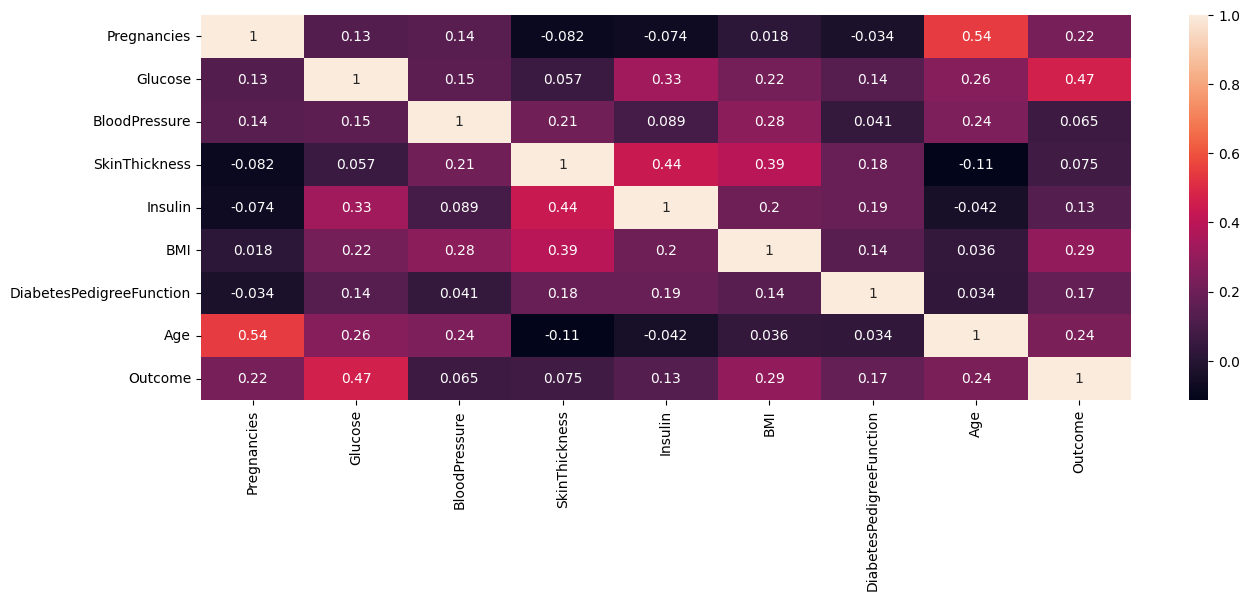

In [ ]:
plt.figure(figsize=(15,5))
ax=sns.heatmap(df.corr(),annot=True)
# plt.savefig("correlation_fig.jpg")
plt.show()

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# **data imputation**

/tmp/ipykernel_572/2164029204.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Pregnancies)


<Axes: xlabel='Pregnancies', ylabel='Density'>

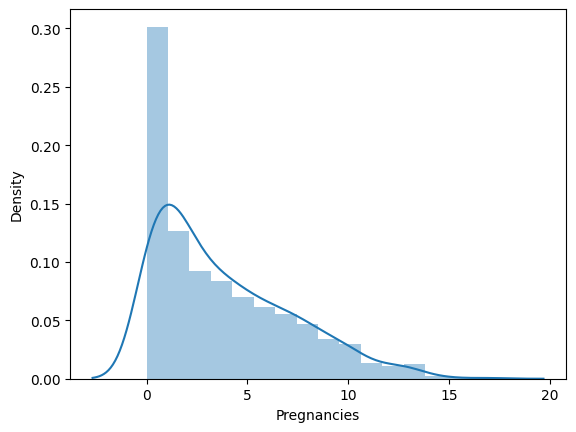

In [ ]:
## use median
sns.distplot(df.Pregnancies)

/tmp/ipykernel_572/2599267228.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Glucose)


<Axes: xlabel='Glucose', ylabel='Density'>

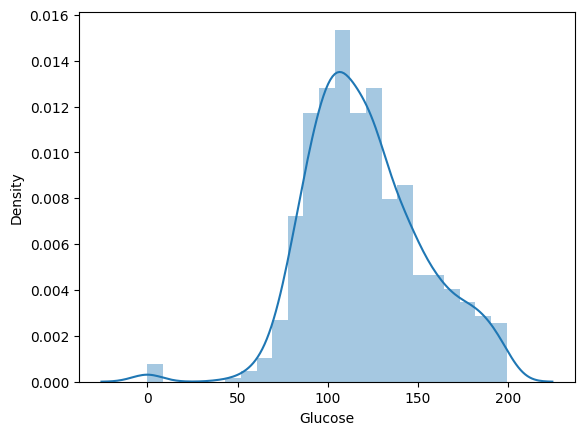

In [ ]:
##use mean
sns.distplot(df.Glucose)

/tmp/ipykernel_572/1391878469.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.BloodPressure)


<Axes: xlabel='BloodPressure', ylabel='Density'>

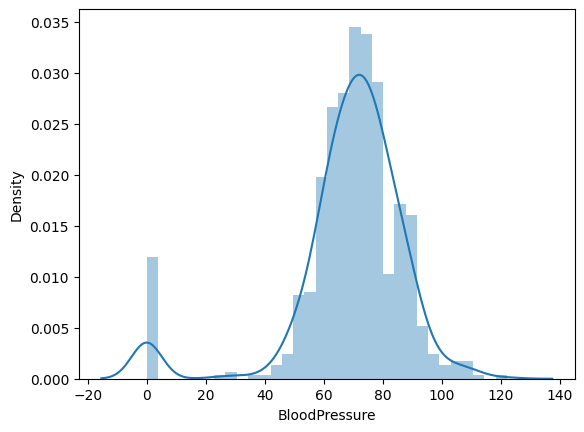

In [ ]:
## use mean
sns.distplot(df.BloodPressure)

/tmp/ipykernel_572/3251846093.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.SkinThickness)


<Axes: xlabel='SkinThickness', ylabel='Density'>

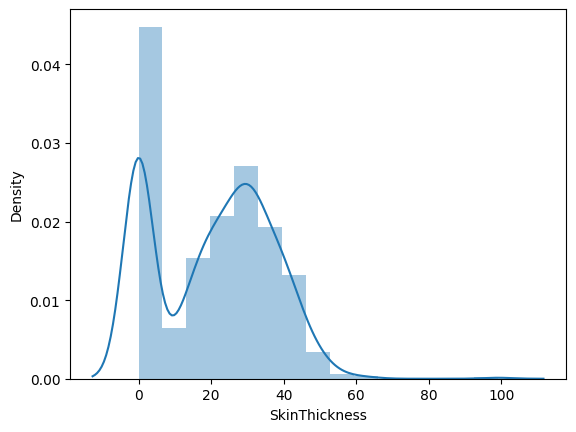

In [ ]:
## use mean
sns.distplot(df.SkinThickness)

/tmp/ipykernel_572/499809343.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Insulin)


<Axes: xlabel='Insulin', ylabel='Density'>

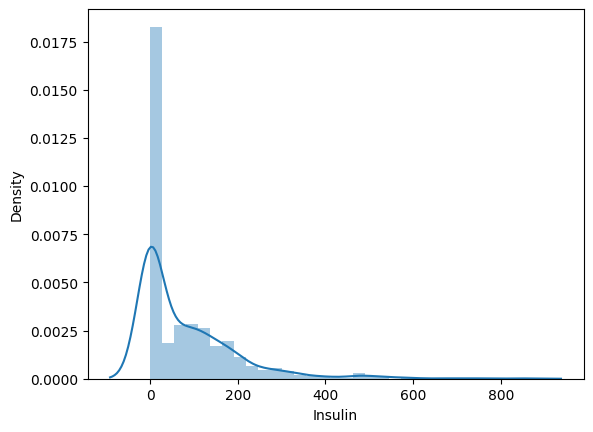

In [ ]:
## medain
sns.distplot(df.Insulin)

/tmp/ipykernel_572/2574655914.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.BMI)


<Axes: xlabel='BMI', ylabel='Density'>

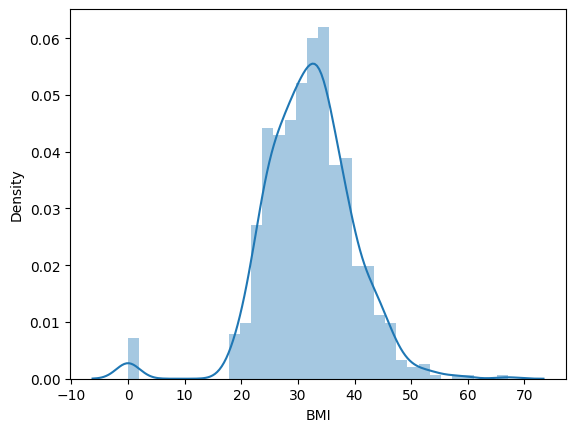

In [ ]:
## use mean
sns.distplot(df.BMI)

/tmp/ipykernel_572/3440444671.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.DiabetesPedigreeFunction)


<Axes: xlabel='DiabetesPedigreeFunction', ylabel='Density'>

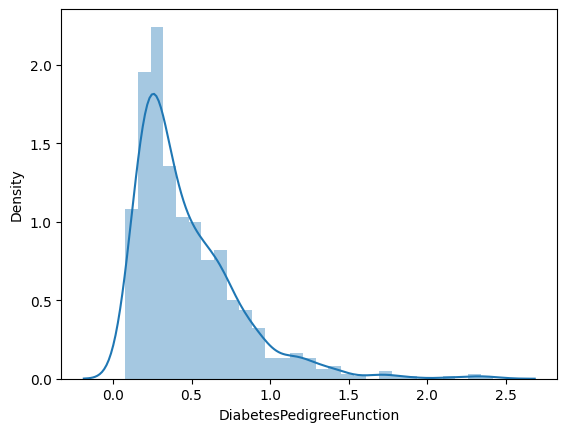

In [ ]:
##use meadian
sns.distplot(df.DiabetesPedigreeFunction)

/tmp/ipykernel_572/1469102531.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Age)


<Axes: xlabel='Age', ylabel='Density'>

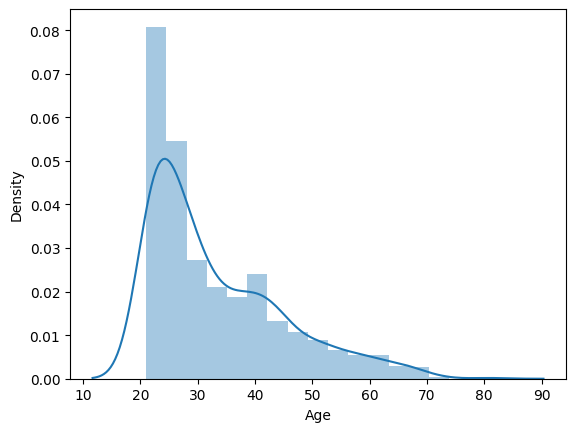

In [ ]:
## use median
sns.distplot(df.Age)

 **data imputation (for numeric data symmertric_> mean and skewed -> median) , use mode for categorical data**

In [ ]:

df['Pregnancies']               =df['Pregnancies'].replace(0,df['Pregnancies'].median())
df['Glucose']                   =df['Glucose'].replace(0,df['Glucose'].mean())
df['BloodPressure']             =df['BloodPressure'].replace(0,df['BloodPressure'].mean())
df['SkinThickness']             =df['SkinThickness'].replace(0,df['SkinThickness'].mean())
df['Insulin']                   =df['Insulin'].replace(0,df['Insulin'].median())
df['BMI']                       =df['BMI'].replace(0,df['BMI'].mean())
df['DiabetesPedigreeFunction']  =df['DiabetesPedigreeFunction'].replace(0,df['DiabetesPedigreeFunction'].median())
df['Age']                       =df['Age'].replace(0,df['Age'].median())

In [ ]:
df.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.000000,35.000000,30.5,33.600000,0.627,50,1
1,1,85.0,66.000000,29.000000,30.5,26.600000,0.351,31,0
2,8,183.0,64.000000,20.536458,30.5,23.300000,0.672,32,1
3,1,89.0,66.000000,23.000000,94.0,28.100000,0.167,21,0
4,3,137.0,40.000000,35.000000,168.0,43.100000,2.288,33,1
5,5,116.0,74.000000,20.536458,30.5,25.600000,0.201,30,0
6,3,78.0,50.000000,32.000000,88.0,31.000000,0.248,26,1
7,10,115.0,69.105469,20.536458,30.5,35.300000,0.134,29,0
8,2,197.0,70.000000,45.000000,543.0,30.500000,0.158,53,1
9,8,125.0,96.000000,20.536458,30.5,31.992578,0.232,54,1


# **outliers**

In [ ]:
X=df.drop(columns="Outcome",axis=1)
Y=df["Outcome"]

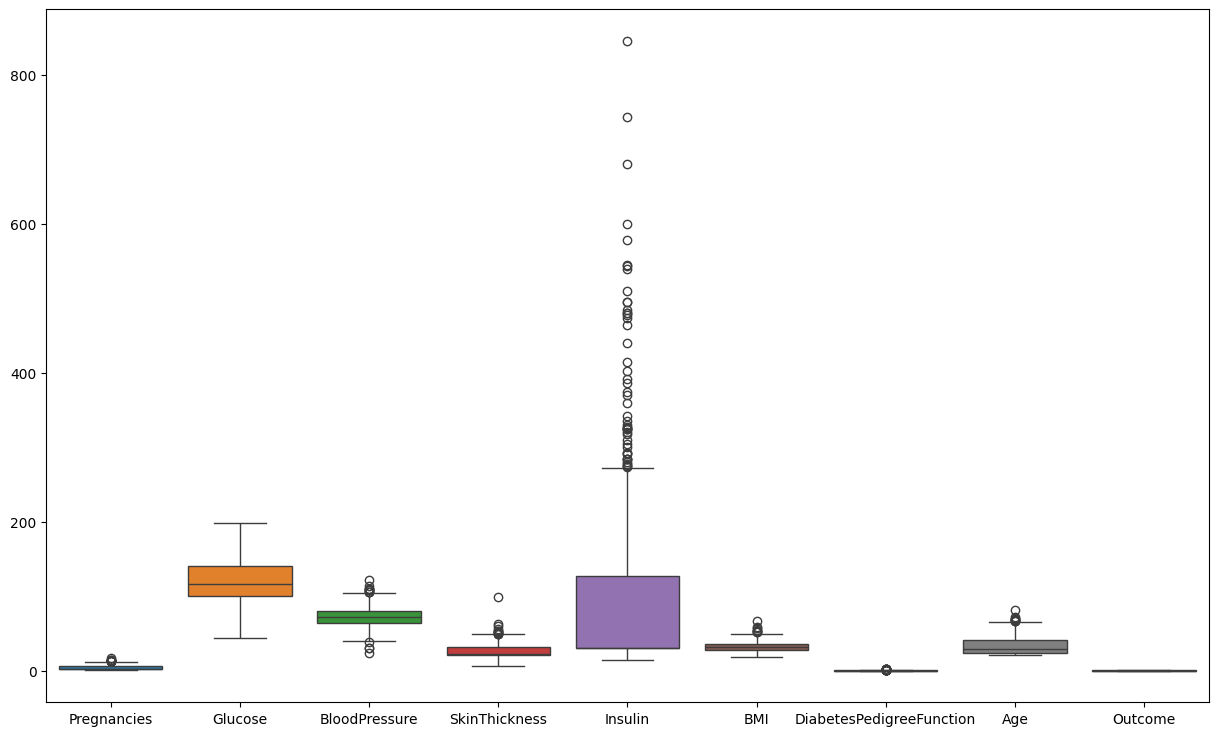

In [ ]:
plt.figure(figsize=(15,9))
sns.boxplot(data=df)
##plt.savefig("outlier.jpg")
plt.show()

**approach 1:outlier removal**

In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
cols=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']
for col in cols:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  lower_limit=Q1-1.5*IQR
  upper_limit=Q3+1.5*IQR
  outliers=(X[col]>=lower_limit) & (X[col]<=upper_limit)

In [ ]:
feature_outlier_removal=X[outliers]
target_outlier_removal=Y[outliers]

In [ ]:
X.shape

(768, 8)

In [ ]:
Y.shape

(768,)

In [ ]:
feature_outlier_removal.shape

(759, 8)

In [ ]:
target_outlier_removal.shape

(759,)

In [ ]:
outliers.head()

,Age
0,True
1,True
2,True
3,True
4,True


# **standared scalar normal form**

In [ ]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
X_scaled=pd.DataFrame(
    scalar.fit_transform(feature_outlier_removal),
    columns=feature_outlier_removal.columns)

In [ ]:
X_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.573222,0.870083,-0.016984,0.863130,-0.612669,0.160901,0.468793,1.548281
1,-1.079800,-1.206570,-0.510935,0.241772,-0.612669,-0.858162,-0.361774,-0.162527
2,1.234430,2.023779,-0.675585,-0.634708,-0.612669,-1.338578,0.604211,-0.072485
3,-1.079800,-1.074719,-0.510935,-0.379585,-0.012978,-0.639792,-0.915485,-1.062953
4,-0.418591,0.507493,-2.651386,0.863130,0.685875,1.543915,5.467240,0.017558


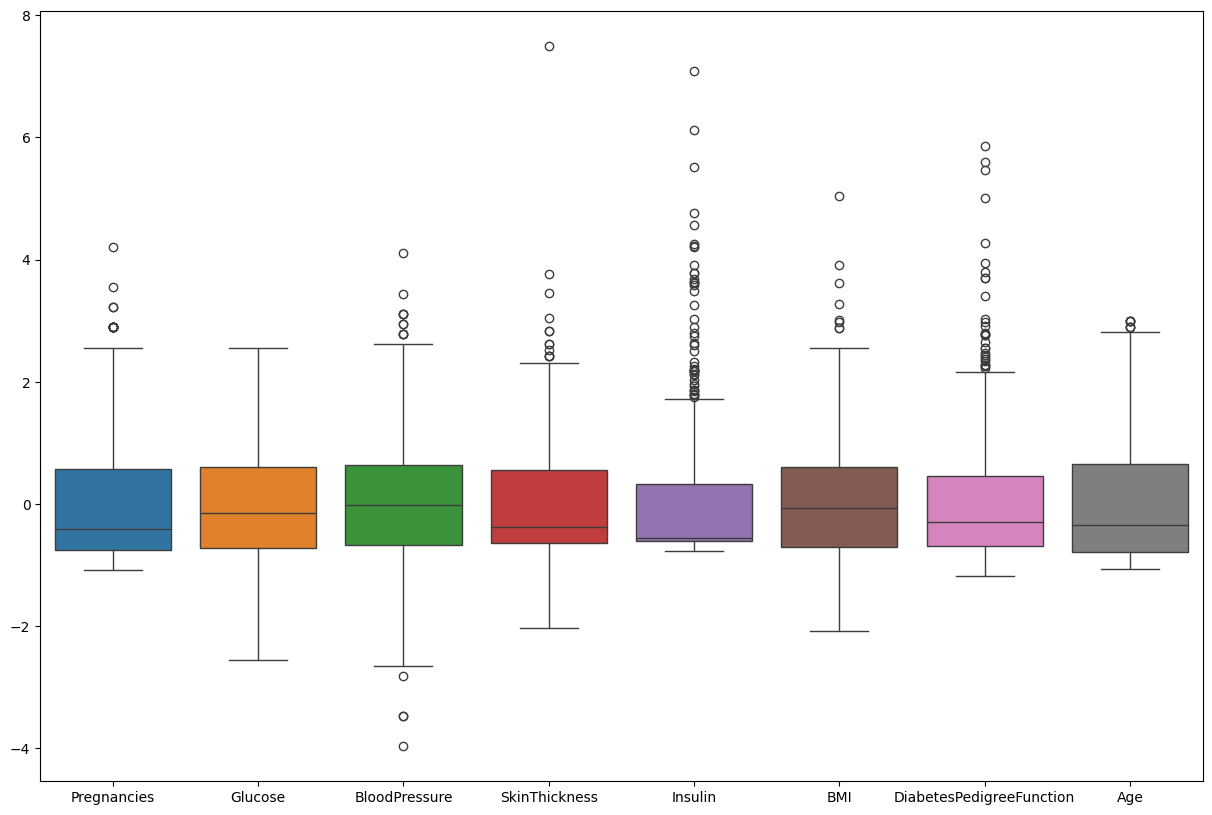

In [ ]:
fig,ax=plt.subplots(figsize=(15,10))
sns.boxplot(data=X_scaled,ax=ax)
# plt.savefig("scaled_fig.jpg")
plt.show()

In [ ]:

X_scaled=pd.DataFrame(X_scaled)
X_scaled.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02
mean,1.029772e-16,-3.978665e-17,-3.042508e-17,-2.012736e-16,-4.329724e-17,5.546727e-16,4.914821e-17,1.591466e-16
std,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00
min,-1.079800e+00,-2.558042e+00,-3.968588e+00,-2.036537e+00,-7.684941e-01,-2.081038e+00,-1.183313e+00,-1.062953e+00
25%,-7.491956e-01,-7.286101e-01,-6.755847e-01,-6.347079e-01,-6.126688e-01,-7.125819e-01,-6.852739e-01,-7.928253e-01
50%,-4.185912e-01,-1.517621e-01,-1.698412e-02,-3.795847e-01,-5.607270e-01,-7.202795e-02,-3.045975e-01,-3.426125e-01
75%,5.732217e-01,6.063810e-01,6.416165e-01,5.524511e-01,3.222827e-01,5.976421e-01,4.627740e-01,6.478556e-01
max,4.209869e+00,2.551183e+00,4.099270e+00,7.490939e+00,7.088876e+00,5.037846e+00,5.864467e+00,2.988962e+00


In [ ]:
Y.value_counts()

,count
Outcome,
0,500
1,268


**approach 2: quantile method**

In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
cols=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']

In [ ]:
X_scaled=pd.DataFrame(X_scaled,columns=cols)
X_scaled.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02
mean,1.029772e-16,-3.978665e-17,-3.042508e-17,-2.012736e-16,-4.329724e-17,5.546727e-16,4.914821e-17,1.591466e-16
std,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00
min,-1.079800e+00,-2.558042e+00,-3.968588e+00,-2.036537e+00,-7.684941e-01,-2.081038e+00,-1.183313e+00,-1.062953e+00
25%,-7.491956e-01,-7.286101e-01,-6.755847e-01,-6.347079e-01,-6.126688e-01,-7.125819e-01,-6.852739e-01,-7.928253e-01
50%,-4.185912e-01,-1.517621e-01,-1.698412e-02,-3.795847e-01,-5.607270e-01,-7.202795e-02,-3.045975e-01,-3.426125e-01
75%,5.732217e-01,6.063810e-01,6.416165e-01,5.524511e-01,3.222827e-01,5.976421e-01,4.627740e-01,6.478556e-01
max,4.209869e+00,2.551183e+00,4.099270e+00,7.490939e+00,7.088876e+00,5.037846e+00,5.864467e+00,2.988962e+00


In [ ]:
df.shape

(768, 9)

In [ ]:
target_outlier_removal.reset_index(drop=True,inplace=True)
X_scaled.reset_index(drop=True,inplace=True)

In [ ]:
q = X_scaled['Insulin'].quantile(.95)
Mask = X_scaled['Insulin'] < q
dataNew = X_scaled[Mask]
target_outlier_removal=target_outlier_removal[Mask]

In [ ]:
X_scaled["BMI"].dtype

dtype('float64')

In [ ]:
target_outlier_removal.shape

(721,)

In [ ]:
dataNew.shape

(721, 8)

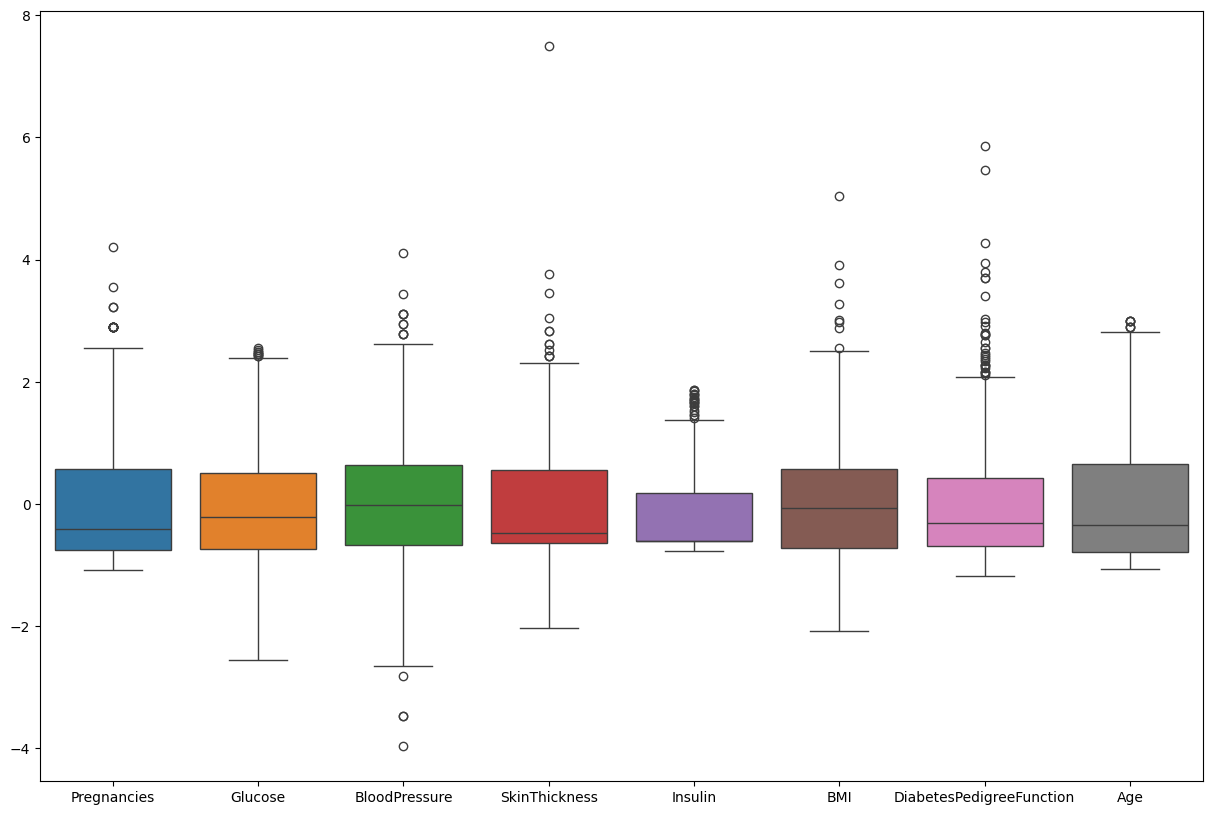

In [ ]:
fig,ax=plt.subplots(figsize=(15,10))
sns.boxplot(data=dataNew,ax=ax)
# plt.savefig("scaled_fig.jpg")
plt.show()

# **Model Training**

splitting the data in the training and testing part

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(dataNew,target_outlier_removal,test_size=.33,random_state=45)

In [ ]:
x_train.shape

(483, 8)

In [ ]:
x_test.shape


(238, 8)

In [ ]:
y_train.value_counts()

,count
Outcome,
0,311
1,172


In [ ]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=45)
x_train_resampled,y_train_resampled=smote.fit_resample(x_train,y_train)


print("using smote to equate the values")
print(pd.Series(y_train_resampled).value_counts())

using smote to equate the values
Outcome
1    311
0    311
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression
classification =LogisticRegression()
classification.fit(x_train_resampled,y_train_resampled)

LogisticRegression()

In [ ]:
y_prediction=classification.predict(x_test)
print(y_prediction)

[0 0 1 0 1 0 1 0 0 1 1 0 1 0 1 1 0 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0 1 0 0 1 0
 1 0 0 1 0 0 0 1 0 0 0 0 1 0 0 1 1 1 0 0 0 0 1 1 1 1 0 1 0 1 0 0 0 1 1 0 0
 0 0 1 0 1 0 1 1 1 0 0 1 0 0 0 0 0 0 1 1 1 0 0 0 1 0 0 1 0 0 1 0 1 0 1 1 0
 1 1 1 0 0 0 1 0 1 0 0 0 1 0 1 1 0 0 1 0 0 1 1 1 0 0 1 1 0 0 0 1 0 0 1 1 1
 1 1 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 0
 0 0 0 0 0 0 0 0 1 0 0 0 1 1 1 1 1 1 0 0 0 0 1 1 0 1 1 1 1 0 1 0 1 1 0 0 0
 1 0 1 0 1 0 1 1 0 1 0 0 0 0 0 1]


**model _evaluvation**

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_prediction)

0.7563025210084033

In [ ]:
from sklearn.metrics import classification_report
target_name=["non_dibetics","dibetics"]
print(classification_report(y_test,y_prediction,target_names=target_name))

              precision    recall  f1-score   support

non_dibetics       0.89      0.75      0.81       166
    dibetics       0.57      0.78      0.66        72

    accuracy                           0.76       238
   macro avg       0.73      0.76      0.73       238
weighted avg       0.79      0.76      0.76       238



In [ ]:
import pickle
pickle.dump(classification,open("classification_model.pkl","wb"))

In [ ]:
classification_model=pickle.load(open("classification_model.pkl","rb"))
classification_model.predict(x_test)

array([0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1])

# **decision tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
tree=DecisionTreeClassifier()
tree.fit(x_train_resampled,y_train_resampled)

DecisionTreeClassifier()

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': range(1, 10, 1),
    'min_samples_leaf': range(1, 20, 2),
    'min_samples_split': range(2, 20, 2),
    'criterion': ["entropy", "gini"]
}

tree = DecisionTreeClassifier(random_state=1)

grid_search = GridSearchCV(estimator=tree, param_grid=param_grid,
                           cv=5, verbose=True)
grid_search.fit(x_train_resampled, y_train_resampled)

Fitting 5 folds for each of 1620 candidates, totalling 8100 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=1),
             param_grid={'criterion': ['entropy', 'gini'],
                         'max_depth': range(1, 10),
                         'min_samples_leaf': range(1, 20, 2),
                         'min_samples_split': range(2, 20, 2)},
             verbose=True)

In [ ]:
df20=df.head(20)
X_=df20.drop(columns="Outcome",axis=1)
Y_=df20["Outcome"]

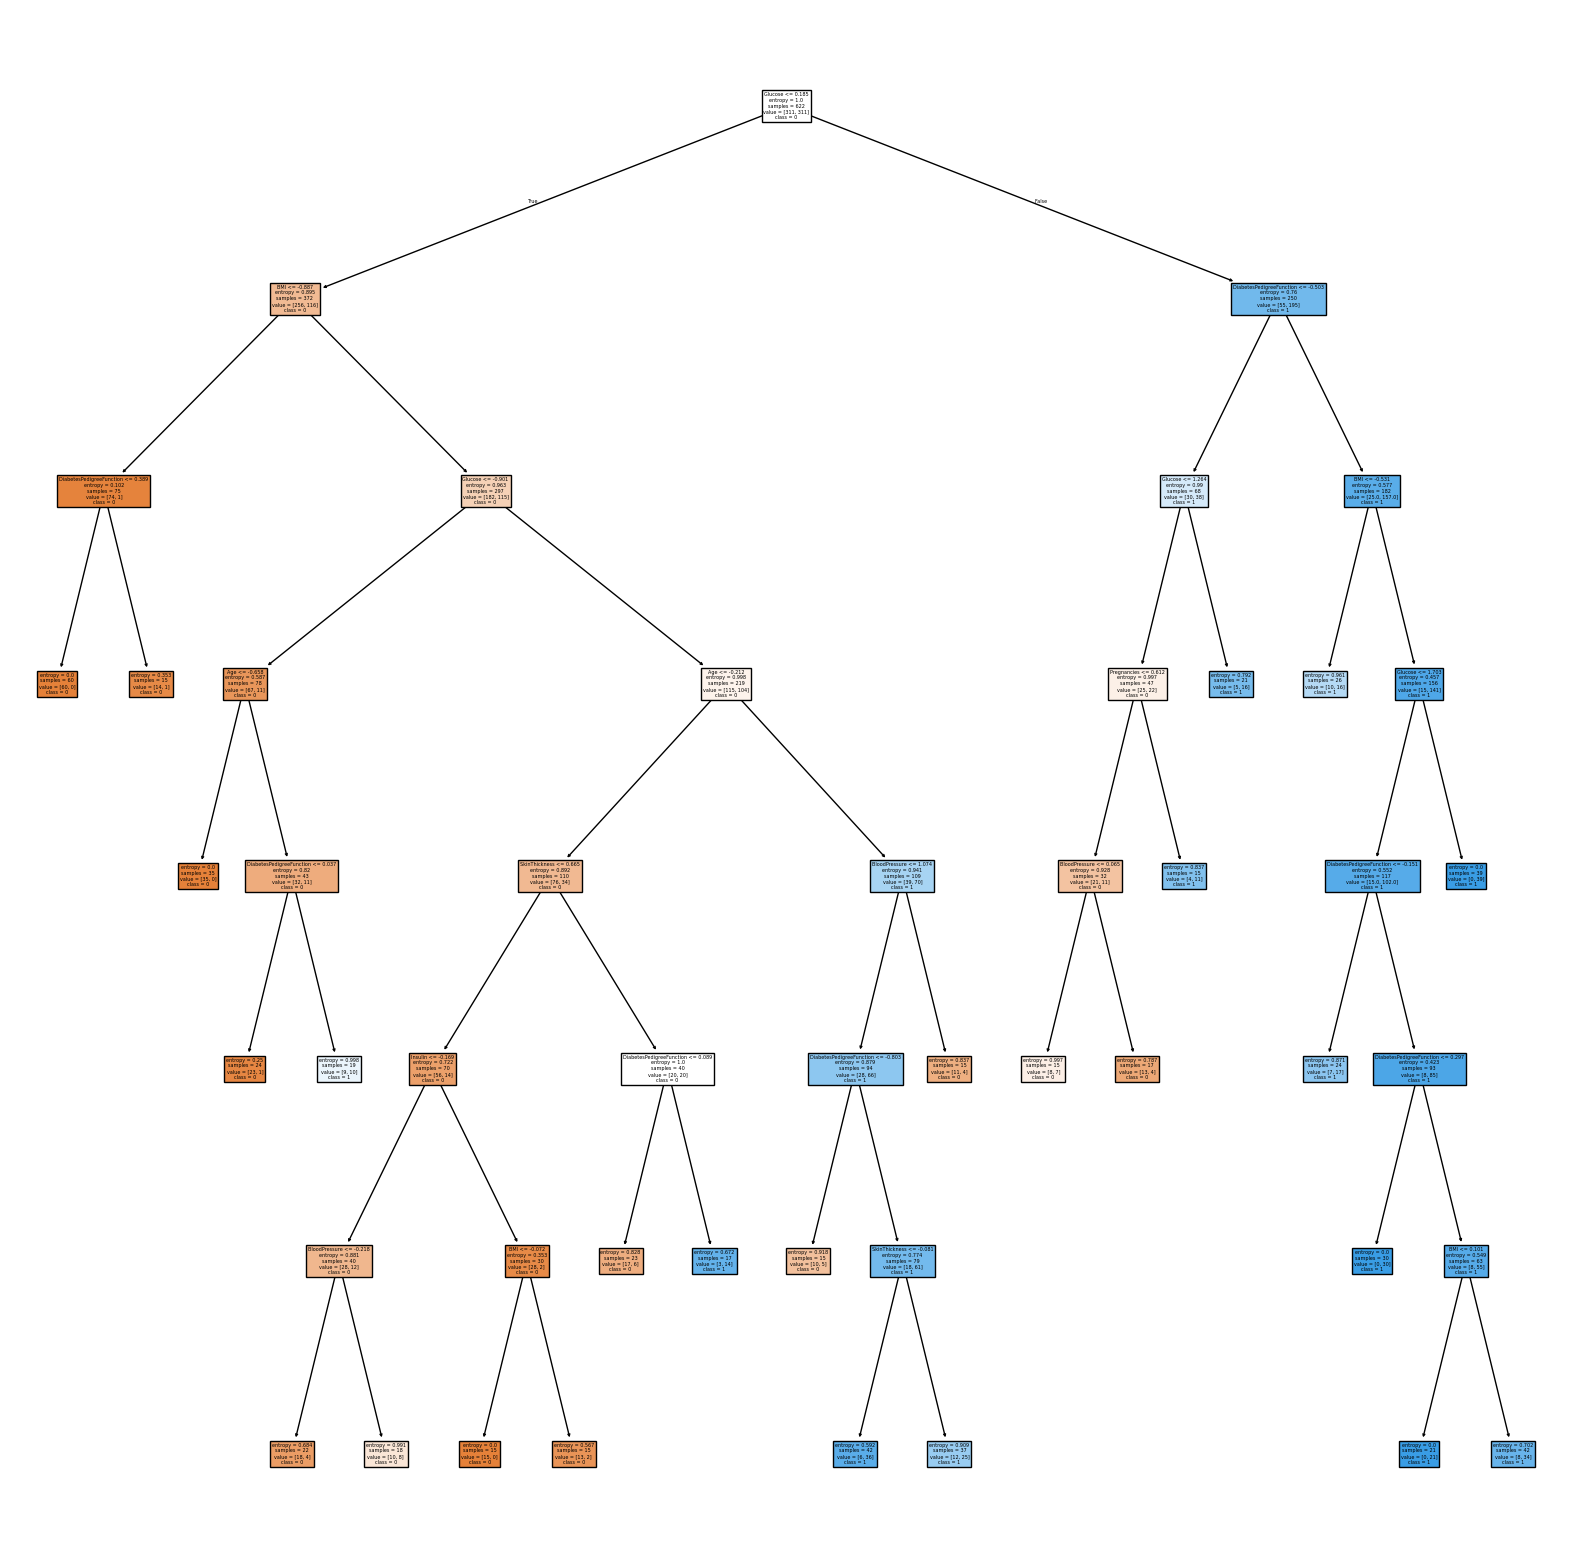

In [ ]:
from sklearn.tree import plot_tree
tree_clf = grid_search.best_estimator_

plt.figure(figsize=(20,20))
plot_tree(tree_clf,filled=True,feature_names=X_.columns,
    class_names=[str(c) for c in sorted(Y_.unique())])
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train_resampled,y_train_resampled)

RandomForestClassifier(random_state=42)

In [ ]:
model_predict=model.predict(x_test)
print(model_predict)

[0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0 1 0 0 1 0
 1 0 0 1 0 0 0 1 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 0 1 1 1 0 0
 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0
 0 1 1 0 0 0 1 0 1 0 1 0 1 0 1 1 0 0 1 0 0 1 0 0 0 0 1 1 0 0 1 1 0 0 1 1 1
 1 0 0 0 1 0 0 0 0 1 0 1 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 1 0 1 1 0 0
 0 0 0 0 0 0 0 0 1 0 0 1 1 0 1 0 1 1 0 0 0 1 1 1 0 1 1 1 1 0 1 0 1 0 0 0 0
 1 0 1 1 1 0 1 1 0 1 0 0 0 0 0 1]


In [ ]:
from sklearn.metrics import accuracy_score,classification_report,mean_squared_error,r2_score
print(accuracy_score(y_test,model_predict))
print(classification_report(y_test,model_predict))
print(mean_squared_error(y_test,model_predict))
print(r2_score(y_test,model_predict))

0.7521008403361344
              precision    recall  f1-score   support

           0       0.85      0.78      0.82       166
           1       0.58      0.68      0.62        72

    accuracy                           0.75       238
   macro avg       0.71      0.73      0.72       238
weighted avg       0.77      0.75      0.76       238

0.24789915966386555
-0.17486613119143257
